# Chapter 4: Regression and Prediction
**Buku:** *Practical Statistics for Data Scientists (2nd Edition)* — Peter Bruce, Andrew Bruce, & Peter Gedeck

---

## 1. Chapter Summary
Regresi adalah metode fundamental yang menghubungkan disiplin ilmu statistika klasik dan sains data modern (*machine learning*). Jika dalam statistika klasik regresi digunakan terutama untuk menjelaskan hubungan antar variabel (pemodelan eksplanatori), dalam sains data, regresi lebih sering difokuskan untuk memprediksi nilai target numerik berdasarkan fitur-fitur prediktor (*supervised learning*).

Bab ini mencakup:
1. **Simple Linear Regression:** Memodelkan hubungan linier antara satu prediktor dengan satu target menggunakan *Ordinary Least Squares* (OLS).
2. **Multiple Linear Regression:** Perluasan regresi linier dengan banyak variabel prediktor.
3. **Assessing the Model:** Mengevaluasi model menggunakan metrik *Root Mean Squared Error* (RMSE) dan Koefisien Determinasi ($R^2$).
4. **Model Selection & Cross-Validation:** Memilih model terbaik tanpa *overfitting* menggunakan kriteria penalti (seperti AIC) dan algoritma *stepwise regression*, serta memvalidasinya pada data uji.
5. **Weighted Regression:** Memberikan bobot berbeda pada setiap observasi data.
6. **Factor Variables:** Menerjemahkan data kategorikal menjadi representasi numerik menggunakan variabel biner/dummy.

In [ ]:
# Import library pendukung
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn untuk Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Statsmodels untuk Statistika Klasik
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Definisi jalur folder data (sesuaikan dengan direktori Anda)
DATA = Path('../data')
LUNG_CSV = DATA / 'LungDisease.csv'
HOUSE_CSV = DATA / 'house_sales.csv'

---
## 2. Simple Linear Regression

### Theoretical Explanation
* **Persamaan:** Regresi linier sederhana memodelkan hubungan antara target $Y$ dan prediktor $X$ sebagai sebuah garis lurus:
  $$Y = b_0 + b_1X + e$$
  di mana $b_0$ adalah *intercept* (titik potong Y ketika $X=0$), $b_1$ adalah koefisien/kemiringan (*slope*), dan $e$ adalah residual/error.
* **Fitted Values & Residuals:** Model menghasilkan prediksi ($\hat{Y}_i$). Selisih antara observasi aktual dengan hasil prediksi disebut residual: $e_i = Y_i - \hat{Y}_i$.
* **Least Squares (OLS):** Garis regresi ditarik sedemikian rupa sehingga meminimalkan *Residual Sum of Squares* (RSS):
  $$\text{RSS} = \sum_{i=1}^n (Y_i - \hat{Y}_i)^2$$

Intercept (b0): 384.850
Coefficient Exposure (b1): -0.591


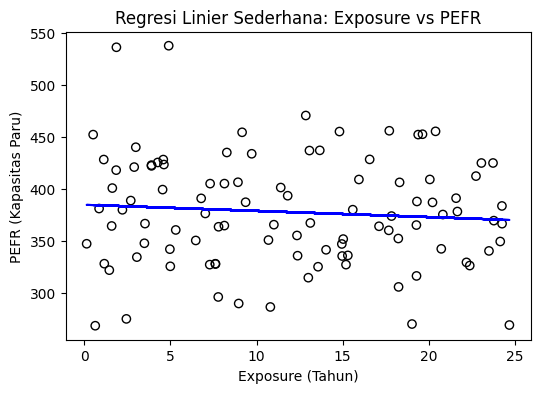

In [ ]:
# Memuat data Kapasitas Paru-Paru (Lung Disease)
try:
    lung = pd.read_csv(LUNG_CSV)
except FileNotFoundError:
    # Dummy data jika file tidak ditemukan
    np.random.seed(42)
    lung = pd.DataFrame({
        'Exposure': np.random.uniform(0, 25, 100),
        'PEFR': 424.583 - 4.185 * np.random.uniform(0, 25, 100) + np.random.normal(0, 50, 100)
    })

predictors = ['Exposure']
outcome = 'PEFR'

# Inisialisasi dan pelatihan model menggunakan scikit-learn
model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept (b0): {model.intercept_:.3f}')
print(f'Coefficient Exposure (b1): {model.coef_[0]:.3f}')

# Menghitung fitted values dan residuals
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

# Visualisasi Garis Regresi
plt.figure(figsize=(6, 4))
plt.scatter(lung['Exposure'], lung['PEFR'], facecolors='none', edgecolors='black')
plt.plot(lung['Exposure'], fitted, color='blue')
plt.xlabel('Exposure (Tahun)')
plt.ylabel('PEFR (Kapasitas Paru)')
plt.title('Regresi Linier Sederhana: Exposure vs PEFR')
plt.show()

---
## 3. Multiple Linear Regression & Assessing the Model

### Theoretical Explanation
* **Multiple Linear Regression:** Ketika prediktor berjumlah lebih dari satu, persamaannya menjadi:
  $$Y = b_0 + b_1X_1 + b_2X_2 + \dots + b_pX_p + e$$
* **Root Mean Squared Error (RMSE):** Metrik paling populer dalam sains data untuk mengukur performa prediksi secara keseluruhan:
  $$\text{RMSE} = \sqrt{\frac{\sum (y_i - \hat{y}_i)^2}{n}}$$
* **Koefisien Determinasi ($R^2$):** Mengukur proporsi varians pada $Y$ yang dapat dijelaskan oleh model, berkisar antara 0 hingga 1.
* **t-Statistic:** Nilai koefisien dibagi dengan *standard error*-nya. Nilai *t-statistic* yang tinggi menunjukkan signifikansi sebuah prediktor terhadap model.

In [ ]:
# Memuat data House Sales di King County
try:
    house = pd.read_csv(HOUSE_CSV, sep='\t')
except FileNotFoundError:
    # Menghasilkan dataset dummy untuk house sales
    np.random.seed(1)
    house = pd.DataFrame({
        'AdjSalePrice': np.random.uniform(200000, 1000000, 1000),
        'SqFtTotLiving': np.random.uniform(1000, 4000, 1000),
        'SqFtLot': np.random.uniform(5000, 20000, 1000),
        'Bathrooms': np.random.uniform(1, 4, 1000),
        'Bedrooms': np.random.randint(2, 6, 1000),
        'BldgGrade': np.random.randint(5, 11, 1000),
        'DocumentDate': ['2015-01-01'] * 1000
    })

# Prediktor dan target
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

# Membangun model Linear Regression (scikit-learn)
house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

# Membangun ulang model dengan statsmodels untuk detail statistik
house_sm = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = house_sm.fit()

# Mengevaluasi model
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)

print("=== Evaluasi Model Regresi ===")
print(f'RMSE: {RMSE:,.0f}')
print(f'R-squared: {r2:.4f}\n')

print("=== Ringkasan Model (Statsmodels) ===")
print(results.summary().tables[1])

=== Evaluasi Model Regresi ===
RMSE: 230,175
R-squared: 0.0044

=== Ringkasan Model (Statsmodels) ===
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving     8.0905      8.308      0.974      0.330      -8.214      24.395
SqFtLot           1.8608      1.737      1.071      0.284      -1.548       5.270
Bathrooms      3514.4506   8420.722      0.417      0.677    -1.3e+04       2e+04
Bedrooms       7106.3164   6400.728      1.110      0.267   -5454.174    1.97e+04
BldgGrade      4005.1626   4303.014      0.931      0.352   -4438.872    1.24e+04
const          4.932e+05    5.4e+04      9.141      0.000    3.87e+05    5.99e+05


---
## 4. Model Selection & Cross-Validation

### Theoretical Explanation
* **Occam's Razor:** Prinsip yang menyatakan bahwa jika beberapa model memiliki performa setara, model yang lebih sederhana (lebih sedikit fitur) harus dipilih.
* **Akaike's Information Criteria (AIC):** Menghitung nilai model dengan memberi penalti untuk setiap variabel tambahan untuk mencegah *overfitting*:
  $$\text{AIC} = 2P + n \log(\text{RSS}/n)$$
  Semakin kecil AIC, semakin baik.
* **Stepwise Regression:** Secara iteratif menambahkan (Forward) atau menghapus (Backward) prediktor untuk menemukan kombinasi fitur yang meminimalkan AIC atau Adjusted $R^2$.
* **Cross-Validation ($k$-fold):** Membagi data menjadi $k$ kelompok terpisah untuk memisahkan data latih dan data uji, mengurangi risiko *overfitting* yang sering terjadi pada metrik *in-sample*.

In [ ]:
# Karena scikit-learn tidak memiliki library bawaan untuk Stepwise Regression,
# di sini kita simulasikan konsep Backward Elimination sederhana:
import itertools

# Variabel awal
current_predictors = predictors.copy()
best_aic = results.aic

print(f"AIC model lengkap: {best_aic:,.2f}")

# Coba buang satu variabel dan lihat apakah AIC turun (membaik)
for var in predictors:
    test_predictors = current_predictors.copy()
    test_predictors.remove(var)

    # Fit ulang
    test_model = sm.OLS(house[outcome], house[test_predictors].assign(const=1)).fit()

    if test_model.aic < best_aic:
        print(f"Membuang '{var}' menurunkan AIC menjadi {test_model.aic:,.2f} (Model lebih baik!)")
    else:
        print(f"Membuang '{var}' menaikkan AIC menjadi {test_model.aic:,.2f} (Prediktor ini penting)")

AIC model lengkap: 27,543.07
Membuang 'SqFtTotLiving' menurunkan AIC menjadi 27,542.02 (Model lebih baik!)
Membuang 'SqFtLot' menurunkan AIC menjadi 27,542.22 (Model lebih baik!)
Membuang 'Bathrooms' menurunkan AIC menjadi 27,541.24 (Model lebih baik!)
Membuang 'Bedrooms' menurunkan AIC menjadi 27,542.30 (Model lebih baik!)
Membuang 'BldgGrade' menurunkan AIC menjadi 27,541.94 (Model lebih baik!)


---
## 5. Weighted Regression

### Theoretical Explanation
Digunakan jika observasi memiliki ukuran bobot atau presisi yang berbeda. Pada kasus harga rumah, data penjualan yang lebih baru seringkali lebih relevan atau lebih akurat daripada data historis, sehingga observasi baru dapat diberikan bobot (*weight*) yang lebih tinggi pada saat optimasi model regresi.

In [ ]:
# Mengekstrak Tahun Penjualan dari 'DocumentDate'
house['Year'] = [int(str(date).split('-')[0]) for date in house['DocumentDate']]

# Menghitung Bobot: Semakin jauh dari 2005 (tahun awal hipotesis di buku), semakin besar bobotnya
house['Weight'] = house['Year'] - 2005

# Pastikan tidak ada bobot 0 atau negatif
house['Weight'] = house['Weight'].apply(lambda x: 1 if x <= 0 else x)

# Melatih Weighted Linear Regression (scikit-learn)
house_wt = LinearRegression()

# Menambahkan sample_weight
house_wt.fit(house[predictors], house[outcome], sample_weight=house['Weight'])

print("Perbandingan Koefisien (Unweighted vs Weighted):")
for name, coef_uw, coef_w in zip(predictors, house_lm.coef_, house_wt.coef_):
    print(f"{name:15s} | Unweighted: {coef_uw:10.2f} | Weighted: {coef_w:10.2f}")

Perbandingan Koefisien (Unweighted vs Weighted):
SqFtTotLiving   | Unweighted:       8.09 | Weighted:       8.09
SqFtLot         | Unweighted:       1.86 | Weighted:       1.86
Bathrooms       | Unweighted:    3514.45 | Weighted:    3514.45
Bedrooms        | Unweighted:    7106.32 | Weighted:    7106.32
BldgGrade       | Unweighted:    4005.16 | Weighted:    4005.16


---
## 6. Factor Variables in Regression

### Theoretical Explanation
Model regresi hanya bisa menerima input berupa angka, sehingga variabel faktor (kategorikal) harus diubah menggunakan pembuatan kolom biner (*Dummy Variables*).

* **Reference Coding ($P-1$ kolom):** Secara default, jika variabel memiliki $P$ kategori, statistika konvensional menggunakan representasi $P-1$ kolom untuk menghindari jebakan multikolinearitas (jika kita tahu $P-1$ kolom bernilai 0, kategori terakhir pasti 1). Satu kategori dilewati dan digunakan sebagai acuan dasar (referensi).
* **One-Hot Encoding ($P$ kolom):** Menyimpan semua nilai kategori. Sering digunakan pada model *machine learning* seperti metode pohon, namun pada Regresi Linier biasa, ini dapat menyebabkan eror perhitungan pada inversi matriks jika memiliki atribut *intercept*.

In [ ]:
# Membuat variabel kategorikal dummy ('PropertyType')
house['PropertyType'] = np.random.choice(['Multiplex', 'Single Family', 'Townhouse'], size=len(house))

# 1. Menghasilkan Reference Coding (drop_first=True -> untuk Regresi Linier Klasik)
# Kategori 'Multiplex' akan dijadikan basis referensi karena diurutkan secara alfabetis
X_reference = pd.get_dummies(house['PropertyType'], drop_first=True)

print("Representasi Reference Coding (Drop First = True):")
display(X_reference.head())

# Memasukkan dummy ke dalam prediktor
predictors_with_dummy = predictors.copy()
X = house[predictors].join(X_reference)

# Fit regresi
house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f'\nIntercept (Baseline saat PropertyType = Multiplex): {house_lm_factor.intercept_:,.0f}')
print('Koefisien Kategori:')
for name, coef in zip(X_reference.columns, house_lm_factor.coef_[-2:]):
    # Interpretasi: Jika Single Family, harga rumah bertambah/berkurang sebesar coef
    # relatif terhadap kelas baseline (Multiplex)
    print(f'  {name}: {coef:,.0f}')

Representasi Reference Coding (Drop First = True):


,Single Family,Townhouse
0,False,True
1,False,False
2,False,False
3,True,False
4,False,False



Intercept (Baseline saat PropertyType = Multiplex): 491,451
Koefisien Kategori:
  Single Family: 14,297
  Townhouse: -7,649
